In [10]:
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta
import itertools, math
from typing import Iterable, Callable

from fxshort_gates import  *
from fxshort_gates import  fxshort_gate_simple_asym
from config import *
from functions2 import *
from gate_tester import *

ImportError: cannot import name 'fxshort_gate_simple_asym' from 'fxshort_gates' (/Users/alexwebb/laptop_coding/risk_matrix/fxshort_gates.py)

In [ ]:


def _k_confirm(signal: pd.Series, k: int) -> pd.Series:
    if k <= 1:
        return signal.astype(bool)
    return (
        signal.astype("int8")
        .rolling(k, min_periods=k)
        .sum()
        .ge(k)
        .astype(bool)
    )

def _compose_entry_signal(slope: pd.Series,
                          slope_entry_threshold: float,
                          carry_ok: pd.Series,
                          require_carry: bool) -> pd.Series:
    slope_down = (slope <= slope_entry_threshold)
    return slope_down & (carry_ok if require_carry else True)

def _compose_reconfirm(slope: pd.Series,
                       slope_exit_threshold: float,
                       carry_ok: pd.Series,
                       require_carry: bool) -> pd.Series:
    # Require down (or strictly below exit threshold) slope to maintain position.
    slope_still_down = slope < slope_exit_threshold
    return slope_still_down & (carry_ok if require_carry else True)



In [ ]:
ticker = 'GBPCHF.FOREX'
START = '2020-01-01'
MAX_AGE = 24
# print(f'START {START}')
# print(f'MAX AGE {MAX_AGE} hours')
params = {
    'from': START,  # EODHD uses from/to
    'to': today,
    'api_token': EOD_API
}
url = (f'https://eodhd.com/api/eod/{ticker}')

df = fetch_csv_robust(url, params=params, ticker=ticker, max_age=MAX_AGE)
s = sort_cols(df)
s= standardize_fx_daily_index(s)

In [ ]:
gate_stateon = fxshort_gate_simple_asym(
    s,
    carry_ann=0.00000000,
    slope_window=6,
    consec=3,
    buffer20=0.000,
    slope_entry_threshold=0.0,
    slope_exit_threshold=0.0,
    require_carry=False,
    grace_days=2, # 3
    avg_rise_window=0,  
    avg_rise_threshold=0,        # use 3-day average-of-N drift kill
    shift_for_signal=True,
    consec_rises_kill=2,
) 
carry_ann = 0.045
gate_stateon = fxshort_gate(
    s,
    carry_ann=carry_ann,
    slope_window=15,
    consec=3,
    buffer20=0.002,
    slope_entry_threshold=-0.0000,
    slope_exit_threshold=-0.0002,
    require_carry=True,
    shift_for_signal=True,
    consec_rises_kill=0, 
)
'''USD TOP RESULTS: win rate .5625, expectancy 0.002058
slope_window=6,
consec=2, 
slope_entry_threshold=-0.0003, 
slope_exit_threshold=-0.0003, 
consec_rises_kill=0, 

GBP TOP RESULTS: win rate .68, expectancy 0.009094
slope_window=15
consec=3,
slope_entry_threshold=0.0,
slope_exit_threshold=-0.0002,
require_carry=True,
consec_rises_kill=0'''


# --- Example usage after you compute gate_stateon ---
trades, stats = analyze_gate_trades(s, gate_stateon, position="short")
print(trades.tail())
print(stats)
# After you get trades from analyze_gate_trades
FEE_PER_TRADE = 0.00004  # 5bp round-trip, adjust as needed
trades["carry_cost"] = trades["holding_days"] * (carry_ann / 365)
trades["fee_cost"] = FEE_PER_TRADE
trades["net_pct_return"] = trades["pct_return"] - trades["carry_cost"] - trades["fee_cost"]

# Recompute summary stats on net_pct_return
net_expectancy = trades["net_pct_return"].mean()
print(f"Net expectancy per trade after carry and fees: {net_expectancy:.5f}")

NameError: name 'fxshort_gate_simple_asym' is not defined

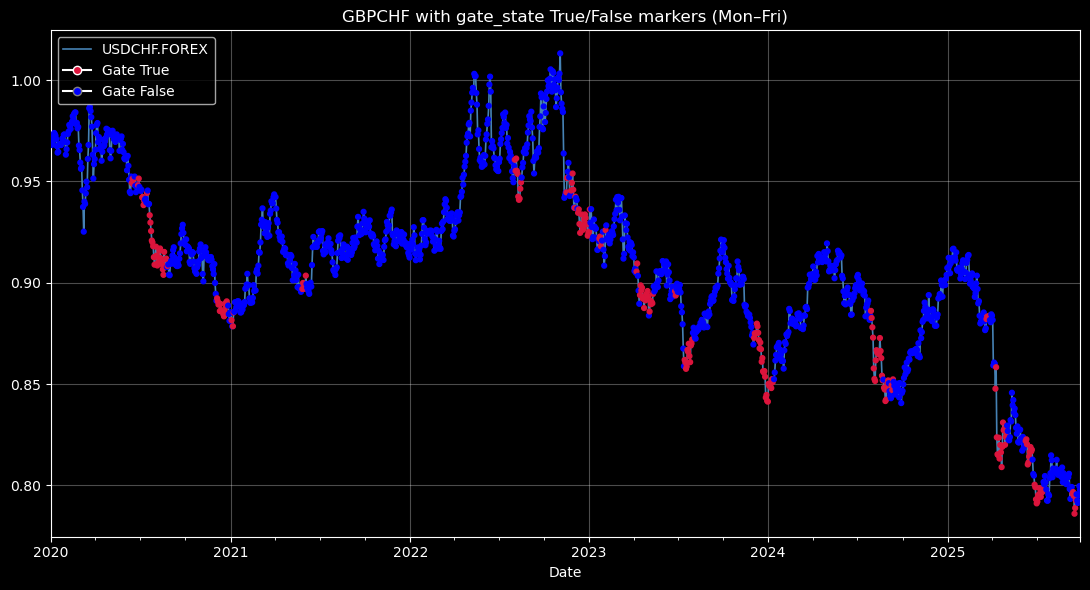

In [ ]:
# Overlay gate_state decisions as per-day True/False markers on the price series
# Assumes you already have `s` (price series) and `gateon` (boolean series) defined
# Set how much tail to display (most recent N bars). Set to None for full history.
plt.style.use('dark_background')

TAIL_BARS = None
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label=ticker)
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title('GBPCHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
results = sweep_fxshort_gate(
    price=s,
    gate_fn=fxshort_gate,        
    slope_window_vals=(4,5,6,8,10,12,15),
    consec_vals=(1,2,3),
    slope_entry_thr_vals=(0.0, -1e-4, -3e-4),
    slope_exit_thr_offsets=(0.0, 1e-4, 2e-4),
    consec_rises_kill_vals=(0,1,2),
    require_carry_vals=(False, True),
    buffer20_vals=(0.002,),
    max_combos=None,
    min_trades=25,
)


In [ ]:
top = summarize_top(results, top=2)
print(top.to_string(index=False))

# top = results.sort_values("expectancy_per_trade", ascending=False)
# print(top.head(10))

 carry_ann  slope_window  consec  slope_entry_thr  slope_exit_thr  require_carry  consec_rises_kill  buffer20  trades  win_rate  expectancy_per_trade  total_pct_return  avg_pct_return  avg_win  avg_loss  median_holding_days  max_draw_trade_pct  best_trade_pct
      0.00            15       3              0.0          0.0002           True                  0     0.001      25  0.680000              0.009094          0.227362        0.009094 0.017031 -0.007771                 16.0           -0.016625        0.060376
      0.02            15       3              0.0          0.0002           True                  0     0.000      27  0.740741              0.008574          0.231500        0.008574 0.014099 -0.007212                 12.0           -0.016510        0.060376
